In [44]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Acer\.cache\kagglehub\datasets\asinow\video_games_sales.csv")
print(df.head())

   rank                      name platform    year         genre publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   na_sales  eu_sales  jp_sales  other_sales  global_sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


In [45]:
df.isnull().sum()

rank              0
name              0
platform          0
year            271
genre             0
publisher        58
na_sales          0
eu_sales          0
jp_sales          0
other_sales       0
global_sales      0
dtype: int64

In [48]:
df.dropna(inplace=True)
df.isnull().sum()

rank            0
name            0
platform        0
year            0
genre           0
publisher       0
na_sales        0
eu_sales        0
jp_sales        0
other_sales     0
global_sales    0
dtype: int64

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          16598 non-null  int64  
 1   name          16598 non-null  object 
 2   platform      16598 non-null  object 
 3   year          16327 non-null  float64
 4   genre         16598 non-null  object 
 5   publisher     16540 non-null  object 
 6   na_sales      16598 non-null  float64
 7   eu_sales      16598 non-null  float64
 8   jp_sales      16598 non-null  float64
 9   other_sales   16598 non-null  float64
 10  global_sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [47]:
df.describe()

,rank,year,na_sales,eu_sales,jp_sales,other_sales,global_sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


                        name  global_sales
0                 Wii Sports         82.74
1          Super Mario Bros.         40.24
2             Mario Kart Wii         35.82
3          Wii Sports Resort         33.00
4   Pokemon Red/Pokemon Blue         31.37
5                     Tetris         30.26
6      New Super Mario Bros.         30.01
7                   Wii Play         29.02
8  New Super Mario Bros. Wii         28.62
9                  Duck Hunt         28.31


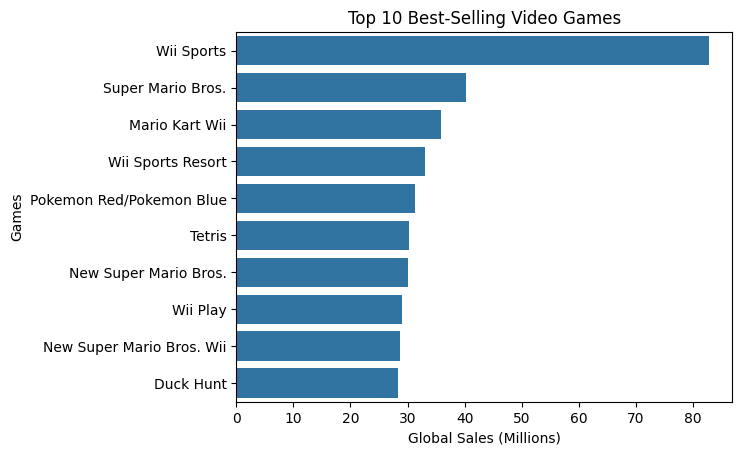

In [49]:
top_games = df[['name', 'global_sales']].sort_values(by='global_sales', ascending=False).head(10)
print(top_games)

import matplotlib.pyplot as plt
import seaborn as sns

df['year'] = df['year'].astype(int)

sns.barplot(x=top_games['global_sales'], y=top_games['name'])
plt.title('Top 10 Best-Selling Video Games')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Games')
plt.show()

Wii Sports is the absolute leader with global sales of 80 million copies. Nintendo dominates the top. This highlights Nintendo's success in creating massive hits.

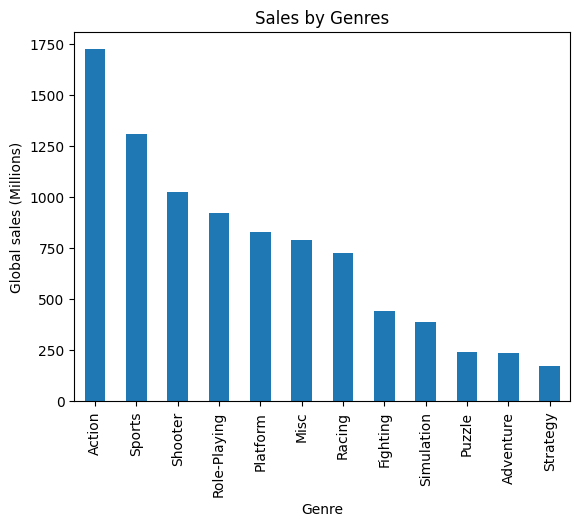

In [50]:
genre_sales = df.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

genre_sales.plot(kind='bar')
plt.title('Sales by Genres')
plt.xlabel('Genre')
plt.ylabel('Global sales (Millions)')
plt.show()

The Sports and Action genres are the leaders in total sales. Role-Playing (for example, Pokémon) also shows high results, especially in Japan.

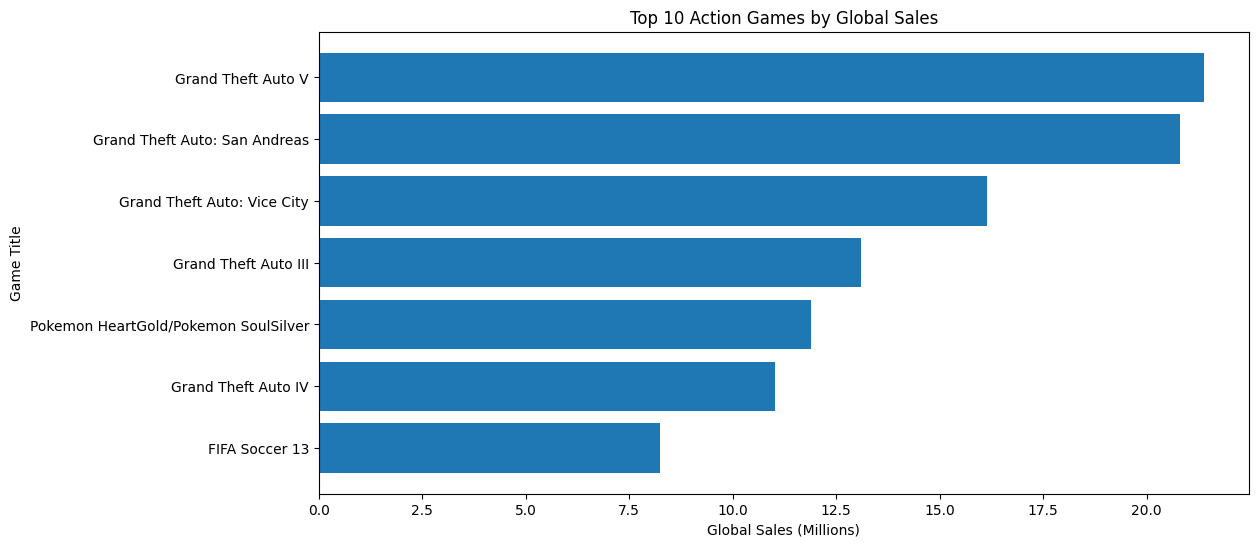

In [51]:
action_games = df[df['genre'] == 'Action']
top_action_games = action_games[['name', 'global_sales']].sort_values(by='global_sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_action_games['name'], top_action_games['global_sales'])
plt.title('Top 10 Action Games by Global Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Game Title')
plt.gca().invert_yaxis() 
plt.show()

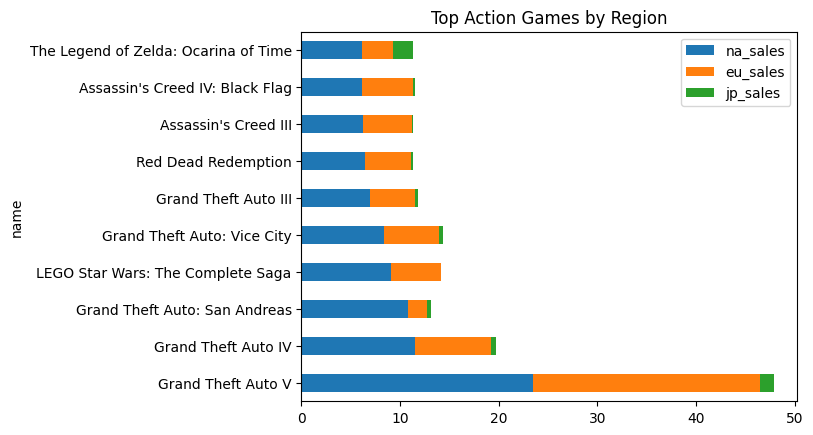

In [52]:
action_games = df[df['genre'] == 'Action']
top_action_regional = action_games.groupby('name')[['na_sales', 'eu_sales', 'jp_sales']].sum().nlargest(10, 'na_sales')

top_action_regional.plot(kind='barh', stacked=True)
plt.title('Top Action Games by Region')
plt.show()

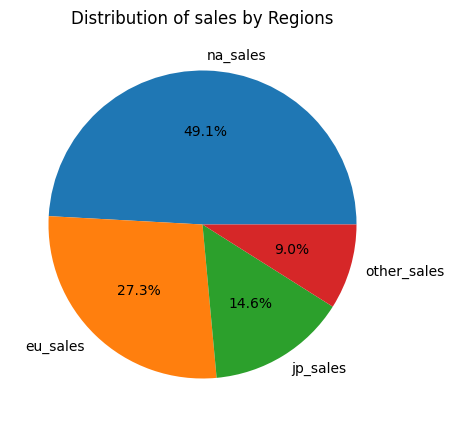

In [53]:
region_sales = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%' , figsize=(5,5))
plt.title('Distribution of sales by Regions')
plt.show()

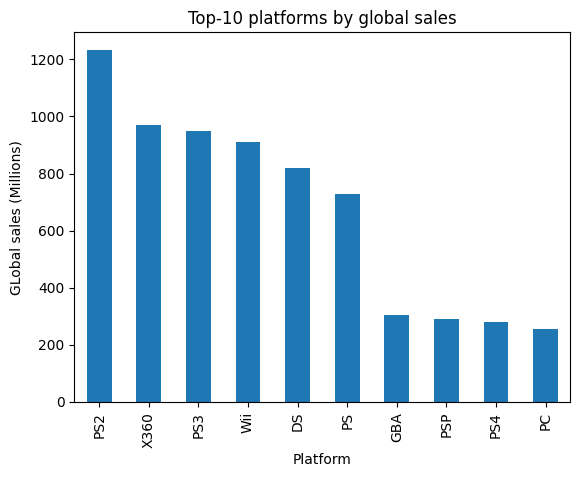

In [54]:
platform_sales = df.groupby('platform')['global_sales'].sum().sort_values(ascending=False).head(10)

platform_sales.plot(kind='bar')
plt.title('Top-10 platforms by global sales')
plt.xlabel('Platform')
plt.ylabel('GLobal sales (Millions)')
plt.show()

Wii, PS2 and PS3 are the leaders in global sales. Nintendo and Sony dominate the market.

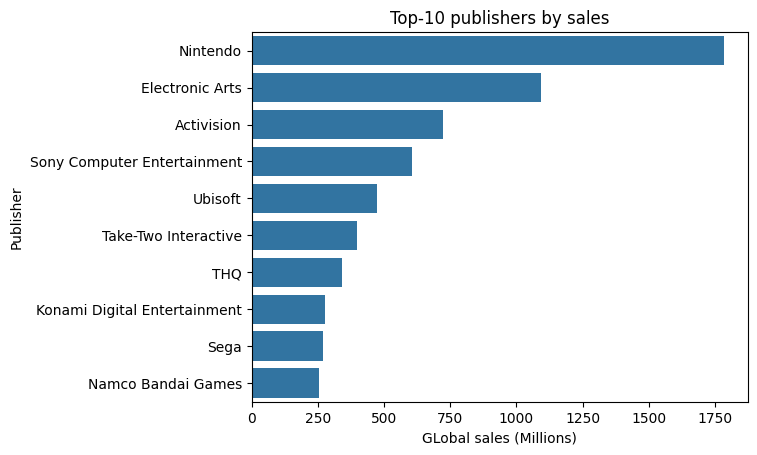

In [55]:
top_publishers = df.groupby('publisher')['global_sales'].sum().nlargest(10).reset_index()

sns.barplot(data=top_publishers, x='global_sales', y='publisher')
plt.title('Top-10 publishers by sales')
plt.xlabel('GLobal sales (Millions)')
plt.ylabel('Publisher')
plt.show()

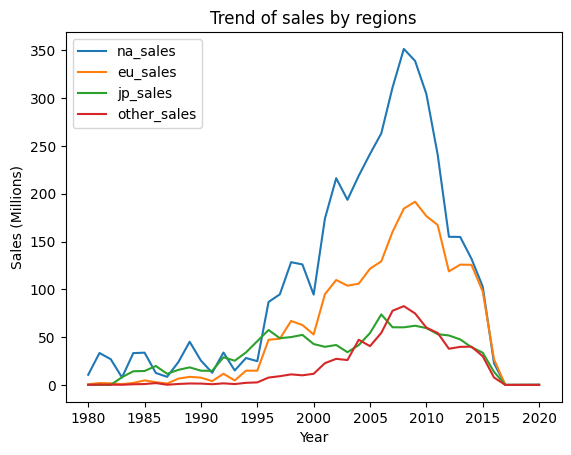

In [56]:
region_trends = df.groupby('year')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

region_trends.plot()
plt.title('Trend of sales by regions')
plt.xlabel('Year')
plt.ylabel('Sales (Millions)')
plt.show()

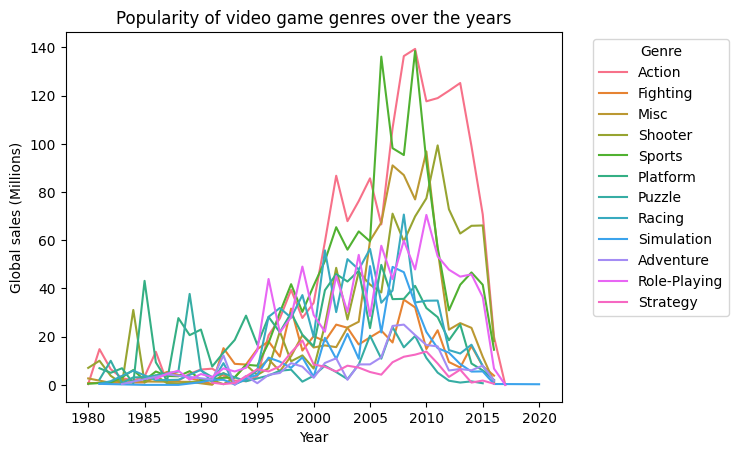

In [57]:
genre_trends = df.groupby(['year', 'genre'])['global_sales'].sum().reset_index()

sns.lineplot(data=genre_trends, x='year', y='global_sales', hue='genre')
plt.title('Popularity of video game genres over the years')
plt.xlabel('Year')
plt.ylabel('Global sales (Millions)')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

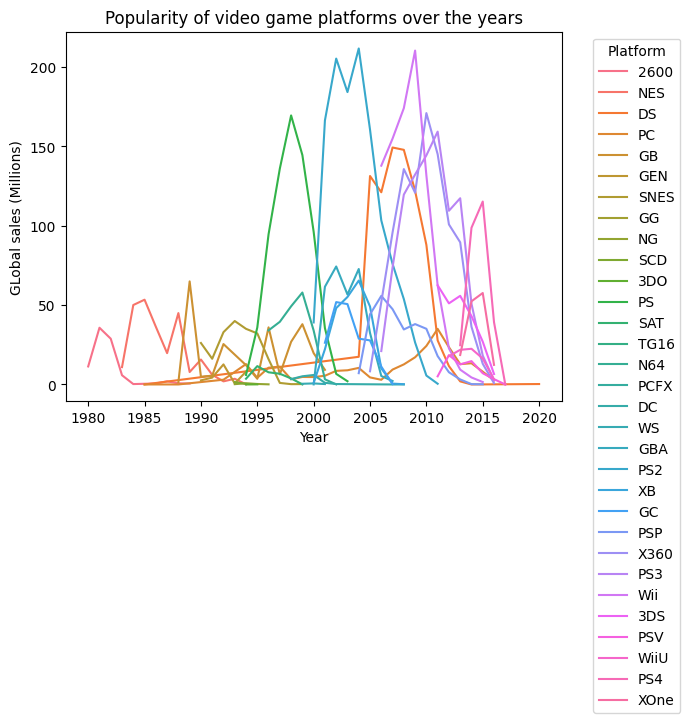

In [58]:
platform_trends = df.groupby(['year', 'platform'])['global_sales'].sum().reset_index()

sns.lineplot(data=platform_trends, x='year', y='global_sales', hue='platform')
plt.title('Popularity of video game platforms over the years')
plt.xlabel('Year')
plt.ylabel('GLobal sales (Millions)')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

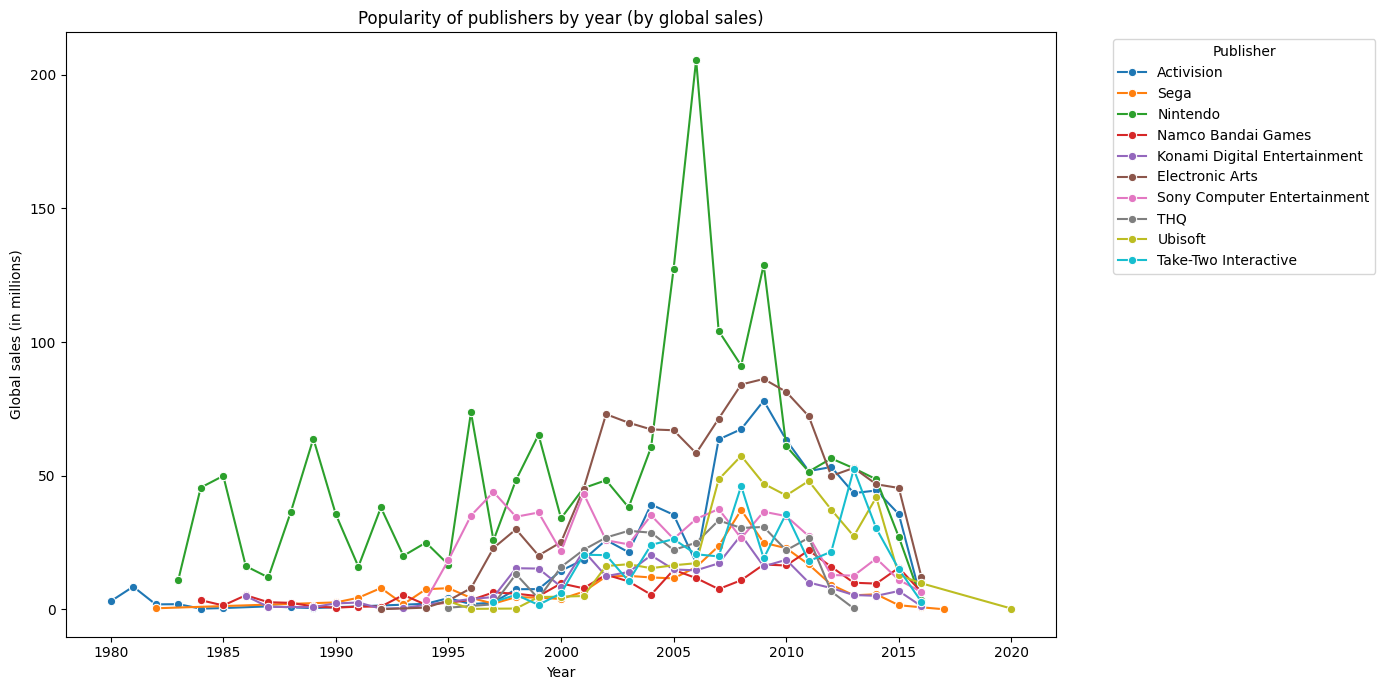

In [59]:
publisher_trends = df.groupby(['year', 'publisher'])['global_sales'].sum().reset_index()

top_publishers = df.groupby('publisher')['global_sales'].sum().nlargest(10).index
publisher_trends_top = publisher_trends[publisher_trends['publisher'].isin(top_publishers)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=publisher_trends_top, x='year', y='global_sales', hue='publisher', marker='o')
plt.title('Popularity of publishers by year (by global sales)')
plt.xlabel('Year')
plt.ylabel('Global sales (in millions)')
plt.legend(title='Publisher', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

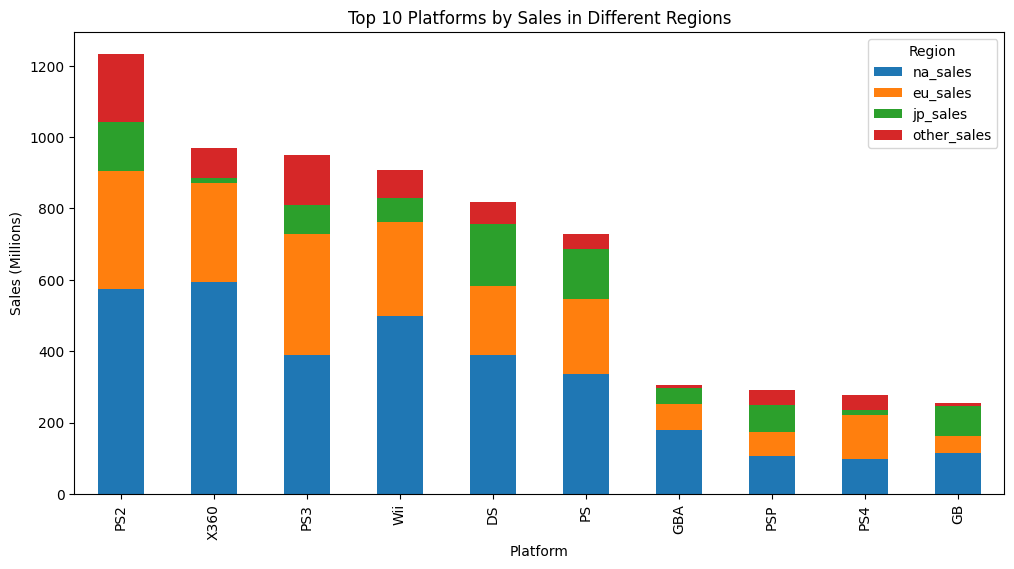

In [60]:
platform_region_sales = df.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

platform_region_sales['total_sales'] = platform_region_sales.sum(axis=1)
top_platforms = platform_region_sales.sort_values('total_sales', ascending=False).head(10).drop('total_sales', axis=1)

top_platforms.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Top 10 Platforms by Sales in Different Regions')
plt.xlabel('Platform')
plt.ylabel('Sales (Millions)')
plt.legend(title='Region')
plt.show()

In [61]:
platform_years = df.groupby('platform')['year'].agg(['min', 'max']).sort_values(by='min', ascending=False)
platform_years

,min,max
platform,,
PS4,2013,2017
XOne,2013,2016
WiiU,2012,2016
PSV,2011,2017
3DS,2011,2016
Wii,2006,2015
PS3,2006,2016
X360,2005,2016
PSP,2004,2015


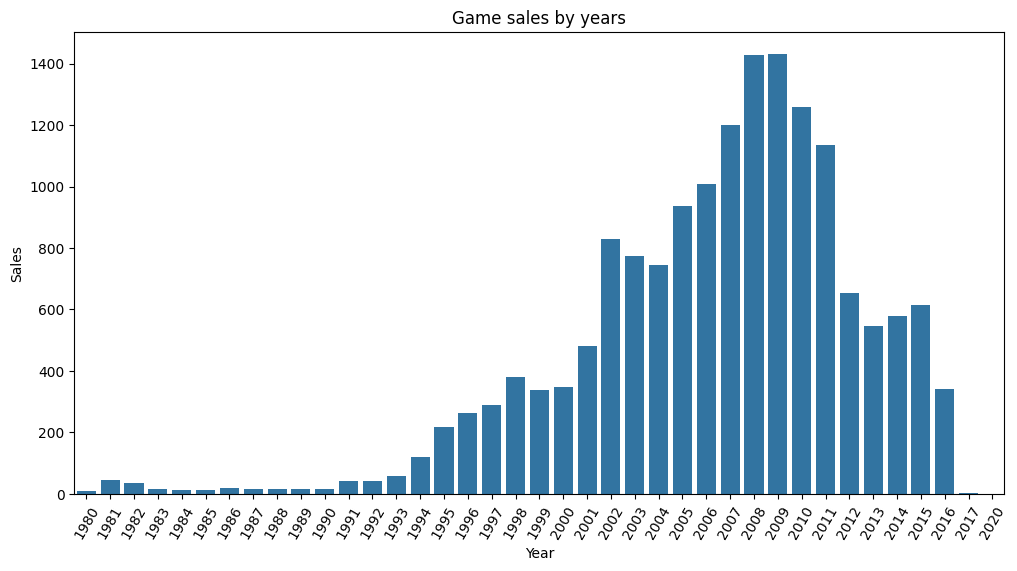

In [62]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='year')
plt.xticks(rotation=60)
plt.title('Game sales by years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

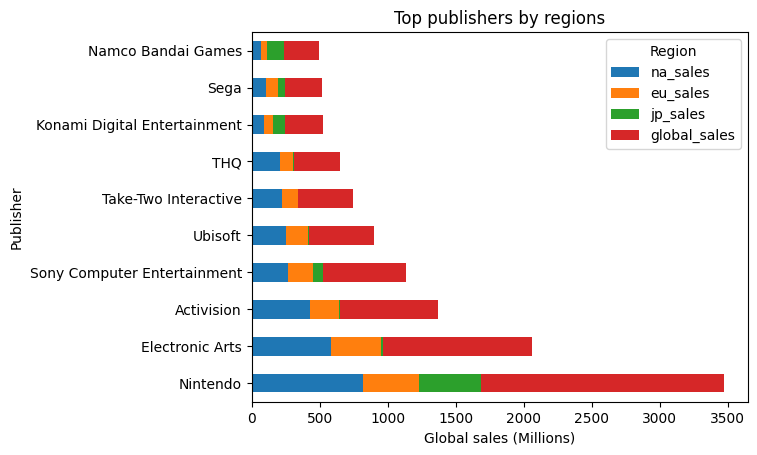

In [63]:
top_publishers = df.groupby('publisher')[['na_sales', 'eu_sales', 'jp_sales', 'global_sales']].sum().nlargest(10, 'global_sales')

top_publishers.plot(kind='barh', stacked=True)
plt.title('Top publishers by regions')
plt.xlabel('Global sales (Millions)')
plt.ylabel('Publisher')
plt.legend(title='Region')
plt.show()

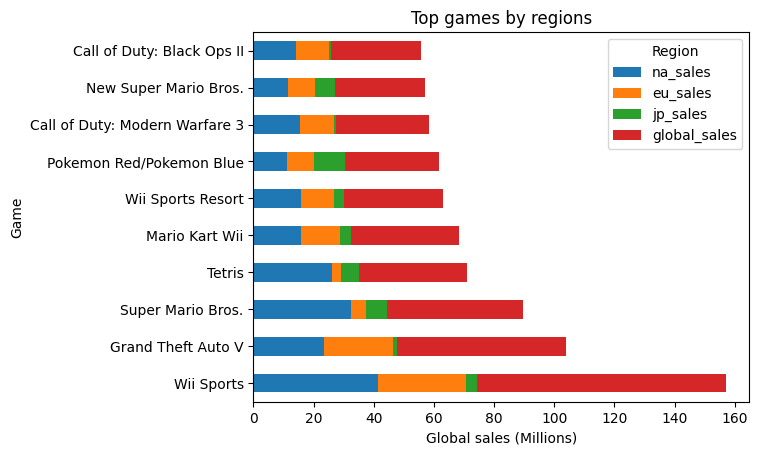

In [64]:
top_games = df.groupby('name')[['na_sales', 'eu_sales', 'jp_sales', 'global_sales']].sum().nlargest(10, 'global_sales')

top_games.plot(kind='barh', stacked=True)
plt.title('Top games by regions')
plt.xlabel('Global sales (Millions)')
plt.ylabel('Game')
plt.legend(title='Region')
plt.show()

            genre                                name  global_sales
16         Action                  Grand Theft Auto V         21.40
50      Adventure  Super Mario Land 2: 6 Golden Coins         11.18
39       Fighting             Super Smash Bros. Brawl         13.04
7            Misc                            Wii Play         29.02
1        Platform                   Super Mario Bros.         40.24
5          Puzzle                              Tetris         30.26
2          Racing                      Mario Kart Wii         35.82
4    Role-Playing            Pokemon Red/Pokemon Blue         31.37
9         Shooter                           Duck Hunt         28.31
10     Simulation                          Nintendogs         24.76
0          Sports                          Wii Sports         82.74
165      Strategy                     Pokemon Stadium          5.45


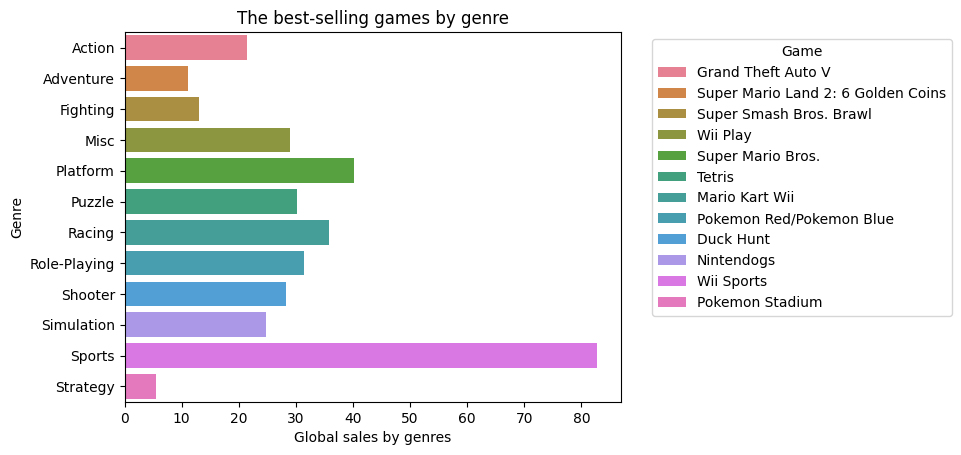

In [65]:
top_games_by_genre = df.loc[df.groupby('genre')['global_sales'].idxmax(), ['genre', 'name', 'global_sales']]
print(top_games_by_genre)

sns.barplot(data=top_games_by_genre, x='global_sales', y='genre', hue='name')
plt.title('The best-selling games by genre')
plt.xlabel('Global sales by genres')
plt.ylabel('Genre')
plt.legend(title='Game', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

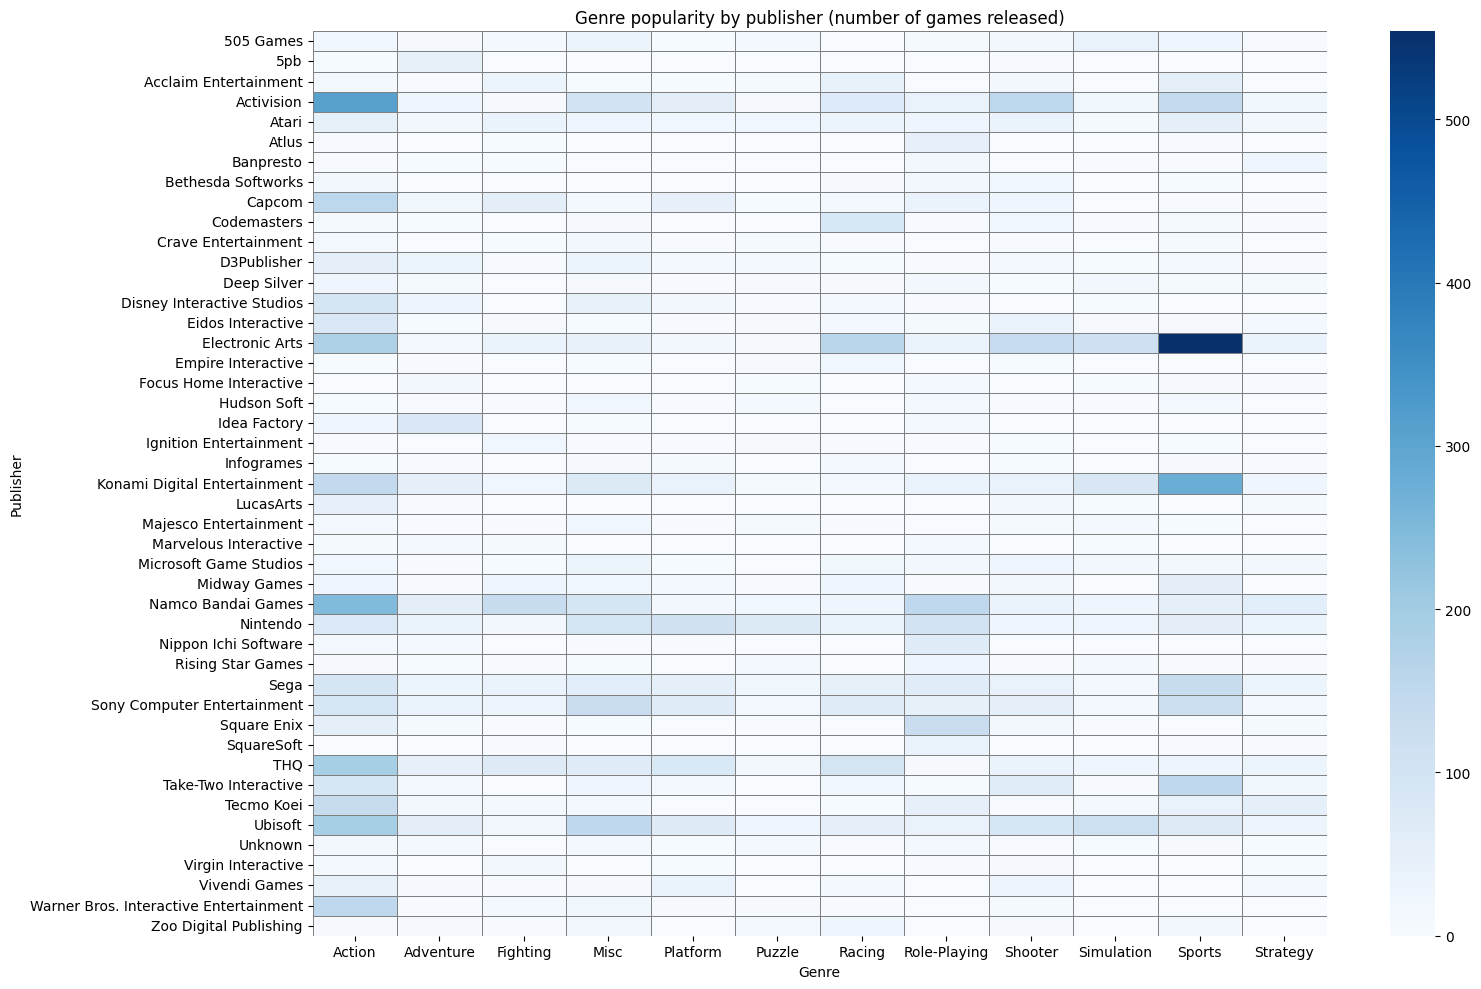

In [66]:
genre_counts = df.groupby(['publisher', 'genre']).size().unstack(fill_value=0)

filtered_publishers = genre_counts.sum(axis=1) > 50
genre_counts_filtered = genre_counts[filtered_publishers]

plt.figure(figsize=(16, 10))
plt.title("Genre popularity by publisher (number of games released)")
sns.heatmap(genre_counts_filtered, cmap='Blues', linewidths=0.5, linecolor='gray')
plt.xlabel("Genre")
plt.ylabel("Publisher")
plt.tight_layout()
plt.show()

                name  na_sales
0         Wii Sports     41.49
1  Super Mario Bros.     29.08
9          Duck Hunt     26.93


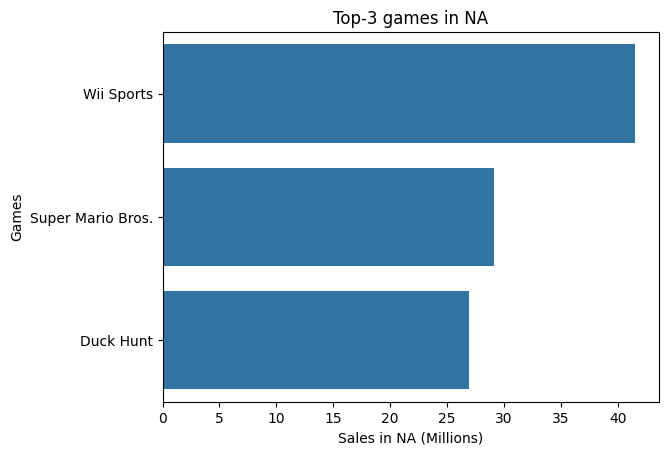

In [67]:
top_na_games = df[['name', 'na_sales']].sort_values(by='na_sales', ascending=False).head(3)
print(top_na_games)

sns.barplot(data=top_na_games, x='na_sales', y='name')
plt.title('Top-3 games in NA')
plt.xlabel('Sales in NA (Millions)')
plt.ylabel('Games')
plt.show()

                name  eu_sales
0         Wii Sports     29.02
2     Mario Kart Wii     12.88
3  Wii Sports Resort     11.01


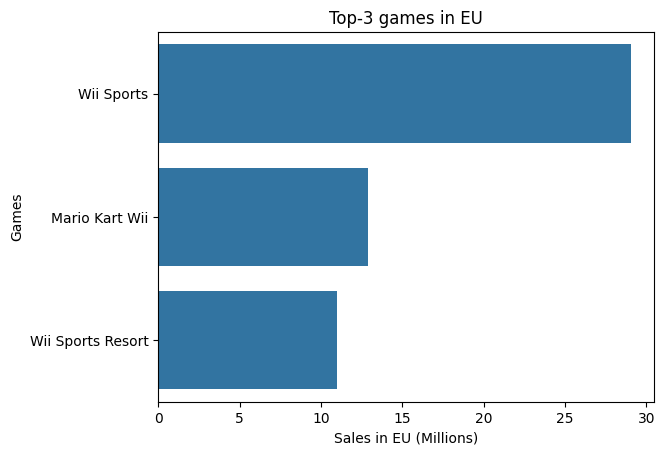

In [68]:
top_eu_games = df[['name', 'eu_sales']].sort_values(by='eu_sales', ascending=False).head(3)
print(top_eu_games)

sns.barplot(data=top_eu_games, x='eu_sales', y='name')
plt.title('Top-3 games in EU')
plt.xlabel('Sales in EU (Millions)')
plt.ylabel('Games')
plt.show()

                           name  jp_sales
4      Pokemon Red/Pokemon Blue     10.22
12  Pokemon Gold/Pokemon Silver      7.20
1             Super Mario Bros.      6.81


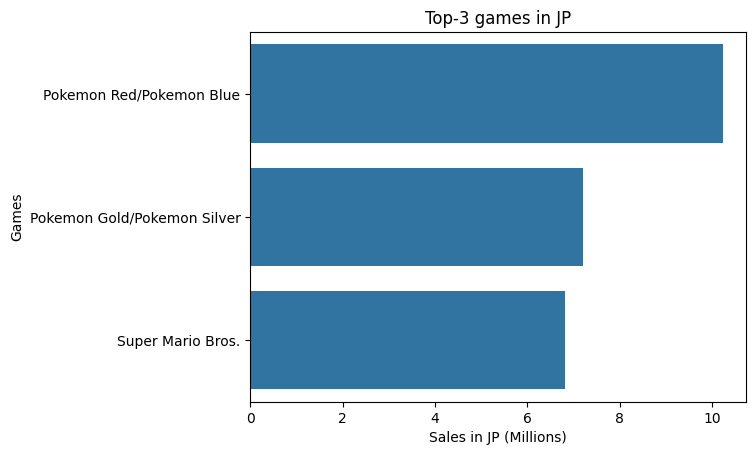

In [69]:
top_jp_games = df[['name', 'jp_sales']].sort_values(by='jp_sales', ascending=False).head(3)
print(top_jp_games)

sns.barplot(data=top_jp_games, x='jp_sales', y='name')
plt.title('Top-3 games in JP')
plt.xlabel('Sales in JP (Millions)')
plt.ylabel('Games')
plt.show()

      genre  na_sales
0    Sports     41.49
1  Platform     29.08
9   Shooter     26.93
5    Puzzle     23.20
2    Racing     15.85


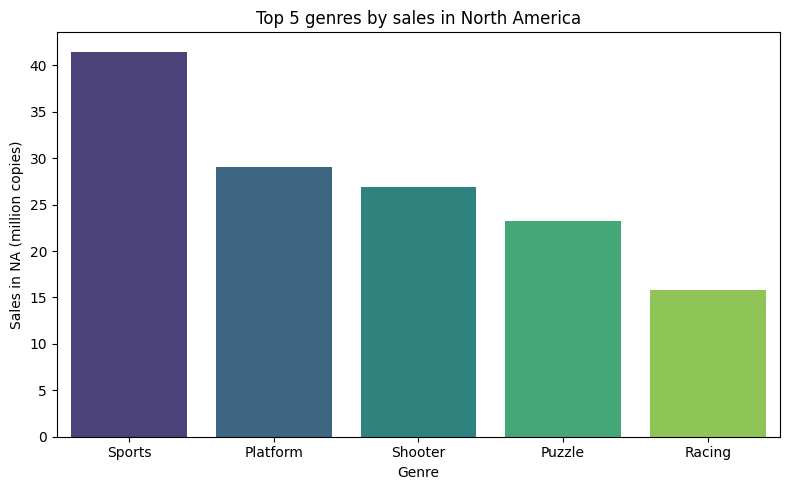

In [70]:
top_na_genres = df[['genre', 'na_sales']].sort_values(by='na_sales', ascending=False).head(5).drop_duplicates(subset='genre')
print(top_na_genres)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_na_genres, x='genre', y='na_sales', hue='genre', palette='viridis', legend=False)
plt.title('Top 5 genres by sales in North America')
plt.xlabel('Genre')
plt.ylabel('Sales in NA (million copies)')
plt.tight_layout()
plt.show()

         genre  eu_sales
0       Sports     29.02
2       Racing     12.88
10  Simulation     11.00
16      Action      9.27


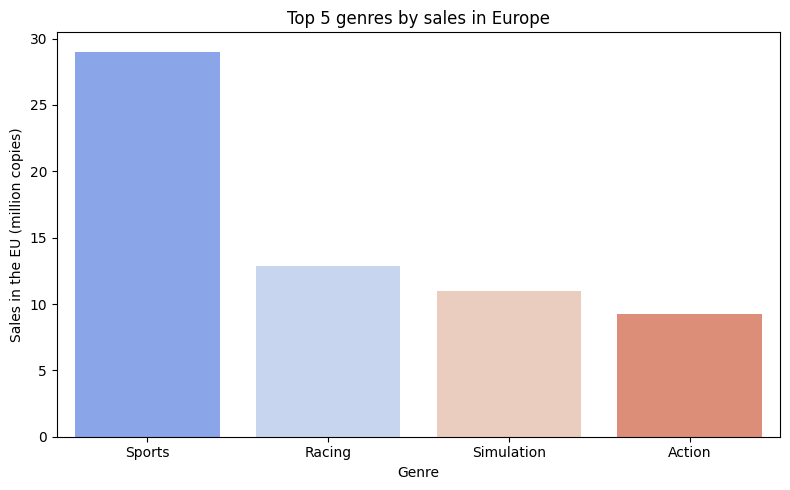

In [71]:
top_eu_genres = df[['genre', 'eu_sales']].sort_values(by='eu_sales', ascending=False).head(5).drop_duplicates(subset='genre')
print(top_eu_genres)


plt.figure(figsize=(8, 5))
sns.barplot(data=top_eu_genres, x='genre', y='eu_sales', hue='genre', palette='coolwarm', legend=False)
plt.title('Top 5 genres by sales in Europe')
plt.xlabel('Genre')
plt.ylabel('Sales in the EU (million copies)')
plt.tight_layout()
plt.show()

          genre  jp_sales
4  Role-Playing     10.22
1      Platform      6.81


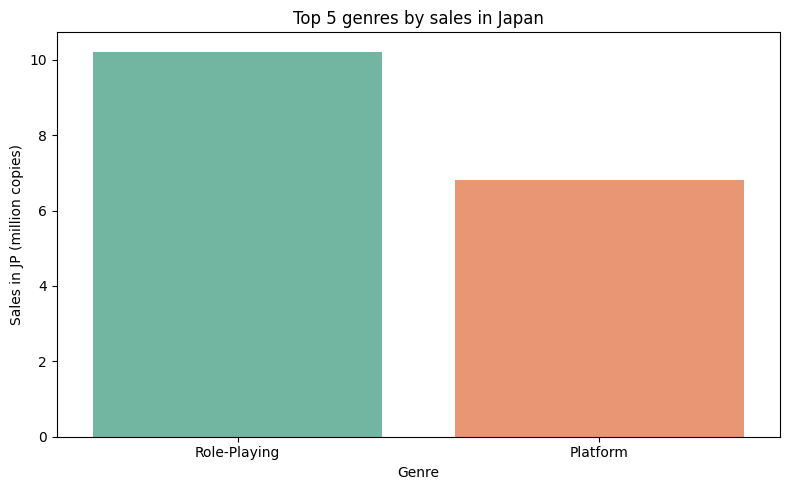

In [72]:
top_jp_genres = df[['genre', 'jp_sales']].sort_values(by='jp_sales', ascending=False).head(5).drop_duplicates(subset='genre')
print(top_jp_genres)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_jp_genres, x='genre', y='jp_sales', hue='genre', palette='Set2', legend=False)
plt.title('Top 5 genres by sales in Japan')
plt.xlabel('Genre')
plt.ylabel('Sales in JP (million copies)')
plt.tight_layout()
plt.show()